In [1]:
import pandas as pd
import numpy as np
import sys, os
from pathlib import Path
from ast import literal_eval
import collections
import json
import pickle
import joblib
import copy

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

#module_path = os.path.abspath(os.path.join('../../'))
#if module_path not in sys.path:
#    sys.path.append(module_path)

In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [14]:
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [15]:
from py.utils import verifyDir

In [16]:
RANDOM_STATE=42
CATEGORY="safety"
N_JOBS=5
DELTA=0.45
GEO_LEVEL="city"
NAME_LEVEL="Rio De Janeiro"
SEGMENT_MODEL="OneFormer_Swin_large/2025-03-29_10:33:12/"

In [23]:
DATA_PATH = f"{repo_path}/data/pp2/"
CSV_PATH=f"{DATA_PATH}raw/"

QSCORE_PATH=f"{DATA_PATH}processed/Qscores/All/Scores/"

IMAGES_PATH=f"{QSCORE_PATH}/{NAME_LEVEL}/Images/"
FEATURES_PATH = f"{DATA_PATH}scene_parsers/{SEGMENT_MODEL}/"

MODEL_PATH = f"{repo_path}/outputs/{NAME_LEVEL}/models/"
CACHE_PATH = f"{repo_path}/outputs/{NAME_LEVEL}/cache/"
EXPLAIN_PATH=f"{repo_path}/outputs/{NAME_LEVEL}/explanations/"

In [18]:
verifyDir(MODEL_PATH)
verifyDir(CACHE_PATH)
verifyDir(EXPLAIN_PATH)

### Loading data

In [21]:
%%time
qscores_df = pd.read_csv(f"{QSCORE_PATH}scores.csv", sep=";", low_memory=False)
qscores_df

CPU times: user 83.8 ms, sys: 30.9 ms, total: 115 ms
Wall time: 114 ms


,image_id,lat,long,city,country,continent,safety,beautiful,wealthy,lively,boring,depressing
0,50e5f7d4d7c3df413b00056a,22.310524,114.170637,Hong Kong,China,Asia,4.135536,1.574074,2.962963,4.199346,5.000000,0.000000
1,50e5f7d4d7c3df413b00056b,22.274799,114.192828,Hong Kong,China,Asia,3.560981,2.229437,5.277778,5.662393,7.777778,3.333333
2,50e5f7d4d7c3df413b00056c,22.291117,114.147373,Hong Kong,China,Asia,4.514946,3.333333,3.333333,4.746693,3.611111,0.000000
3,50e5f7d4d7c3df413b00056d,22.314273,114.177176,Hong Kong,China,Asia,4.852448,3.333333,5.083333,3.333333,8.333333,3.327381
4,50e5f7d4d7c3df413b00056e,22.332412,114.204790,Hong Kong,China,Asia,4.975207,2.129630,3.680556,4.343857,2.500000,4.444444
...,...,...,...,...,...,...,...,...,...,...,...,...
108815,5185d533fdc9f03fd500148e,45.581265,-73.511511,Montreal,Canada,North America,4.797811,3.251984,2.777778,2.148291,7.222222,7.777778
108816,5185d534fdc9f03fd500148f,45.591299,-73.520681,Montreal,Canada,North America,5.006830,6.888889,7.777778,6.176471,5.833333,2.611111
108817,5185d534fdc9f03fd5001490,45.470656,-73.631901,Montreal,Canada,North America,4.551622,3.333333,5.000000,5.008547,3.611111,2.962963
108818,5185d536fdc9f03fd5001491,45.626787,-73.547511,Montreal,Canada,North America,4.666846,2.833333,3.333333,4.376984,3.666667,5.777778


In [24]:
%%time
segmentation_df = pd.read_csv(f"{FEATURES_PATH}segmentations.csv", sep=";", low_memory=False)
segmentation_df

CPU times: user 730 ms, sys: 131 ms, total: 861 ms
Wall time: 860 ms


,image_id,city,image_path,bicycle,building,car,person,plant,pot,road,...,crt,monitor,seat,bar,cushion,case,pool,chandelier,microwave,stove
0,513d564efdc9f03587002f73,Amsterdam,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,1.651667,30.939167,0.421667,0.364167,4.286667,0.8825,15.708333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,513d564ffdc9f03587002f74,Amsterdam,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,0.000000,14.285000,13.425833,0.000000,4.655833,0.0000,25.182500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,513d564ffdc9f03587002f75,Amsterdam,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,0.000000,0.000000,0.000000,0.000000,3.485000,0.0000,35.925833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,513d5650fdc9f03587002f76,Amsterdam,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,0.000000,0.240000,0.203333,0.000000,0.000000,0.0000,33.764167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,513d5651fdc9f03587002f77,Amsterdam,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,0.000000,29.627500,0.000000,0.072500,0.000000,0.0000,37.623333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108433,5140ba43fdc9f04926001f98,Zagreb,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,0.000000,4.878333,0.057500,0.000000,0.119167,0.0000,28.663333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108434,5140ba45fdc9f04926001f99,Zagreb,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,0.000000,0.000000,0.135000,0.000000,0.000000,0.0000,32.985833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108435,5140ba46fdc9f04926001f9a,Zagreb,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,0.000000,28.957500,0.093333,0.000000,1.345833,0.0000,11.492500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108436,5140ba47fdc9f04926001f9b,Zagreb,/media/felipe/DATA12/github/FGV/PlacePulse/dat...,0.000000,0.865000,3.667500,0.000000,0.085833,0.0000,29.710833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
data_df = pd.merge(qscores_df, segmentation_df, on="image_id", how="left")
data_df.dropna(inplace=True)
data_df.sort_values(by=[CATEGORY], inplace=True, ascending=False)
data_df

,image_id,lat,long,city_x,country,continent,safety,beautiful,wealthy,lively,...,crt,monitor,seat,bar,cushion,case,pool,chandelier,microwave,stove
98448,51414746fdc9f04926006a00,44.961377,-93.271491,Minneapolis,USA,North America,8.780423,7.500000,7.777778,6.278770,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42970,513d677cfdc9f035870040af,42.370774,-71.126977,Boston,USA,North America,8.583389,5.333333,6.055556,5.029020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50759,513d7c38fdc9f03587006e0f,33.805683,-84.293833,Atlanta,USA,North America,8.505291,6.342593,8.452381,2.291667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16909,50f5642cfdc9f065f00060f0,47.583294,-122.287884,Seattle,USA,North America,8.478006,7.166667,7.500000,5.538597,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33004,513cc19efdc9f035870014bd,29.751635,-95.466232,Houston,USA,North America,8.440027,7.592593,6.653439,4.321429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780,50f42c0bfdc9f065f0001786,52.242431,20.898414,Warsaw,Poland,Europe,0.392157,5.899471,2.833333,4.872958,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67667,513e6bb5fdc9f0358700c081,35.646141,139.812366,Tokyo,Japan,Asia,0.277778,3.333333,3.333333,4.538332,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15653,50f562dafdc9f065f0005ae6,1.292158,103.808340,Singapore,Singapore,Asia,0.256410,4.305556,3.333333,6.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68843,513e6f20fdc9f0358700c51f,35.743776,139.773877,Tokyo,Japan,Asia,0.196078,5.092593,3.080808,6.603175,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
data_df.loc[:, (data_df != 0).any(axis=0)]

,image_id,lat,long,city_x,country,continent,safety,beautiful,wealthy,lively,...,crt,monitor,seat,bar,cushion,case,pool,chandelier,microwave,stove
98448,51414746fdc9f04926006a00,44.961377,-93.271491,Minneapolis,USA,North America,8.780423,7.500000,7.777778,6.278770,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42970,513d677cfdc9f035870040af,42.370774,-71.126977,Boston,USA,North America,8.583389,5.333333,6.055556,5.029020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50759,513d7c38fdc9f03587006e0f,33.805683,-84.293833,Atlanta,USA,North America,8.505291,6.342593,8.452381,2.291667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16909,50f5642cfdc9f065f00060f0,47.583294,-122.287884,Seattle,USA,North America,8.478006,7.166667,7.500000,5.538597,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33004,513cc19efdc9f035870014bd,29.751635,-95.466232,Houston,USA,North America,8.440027,7.592593,6.653439,4.321429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780,50f42c0bfdc9f065f0001786,52.242431,20.898414,Warsaw,Poland,Europe,0.392157,5.899471,2.833333,4.872958,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67667,513e6bb5fdc9f0358700c081,35.646141,139.812366,Tokyo,Japan,Asia,0.277778,3.333333,3.333333,4.538332,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15653,50f562dafdc9f065f0005ae6,1.292158,103.808340,Singapore,Singapore,Asia,0.256410,4.305556,3.333333,6.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68843,513e6f20fdc9f0358700c51f,35.743776,139.773877,Tokyo,Japan,Asia,0.196078,5.092593,3.080808,6.603175,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Filtering by city

In [27]:
if GEO_LEVEL.lower()!="all":
    data_df = data_df[data_df[GEO_LEVEL]==NAME_LEVEL].copy()

KeyError: 'city'

##### Selecting samples

In [28]:
top_n = int(len(data_df) * DELTA)
top_df = data_df.nlargest(top_n, CATEGORY)
top_df["labels"] = "safe"
bot_df = data_df.nsmallest(top_n, CATEGORY)
bot_df["labels"] = "unsafe"
print(f"Top max: {top_df[CATEGORY].max()}, min:{top_df[CATEGORY].min()}\nBot max: {bot_df[CATEGORY].max()}, min:{bot_df[CATEGORY].min()}")
delta_df = pd.concat([top_df, bot_df], ignore_index=True)
delta_df.sort_values(by=[CATEGORY], inplace=True,ascending=False)
delta_df["labels"].value_counts()

Top max: 8.78042328042328, min:4.863112993530951
Bot max: 4.594296906796908, min:0.0


labels
safe      48797
unsafe    48797
Name: count, dtype: int64

##### Visualizating object presence

TypeError: '>' not supported between instances of 'str' and 'int'

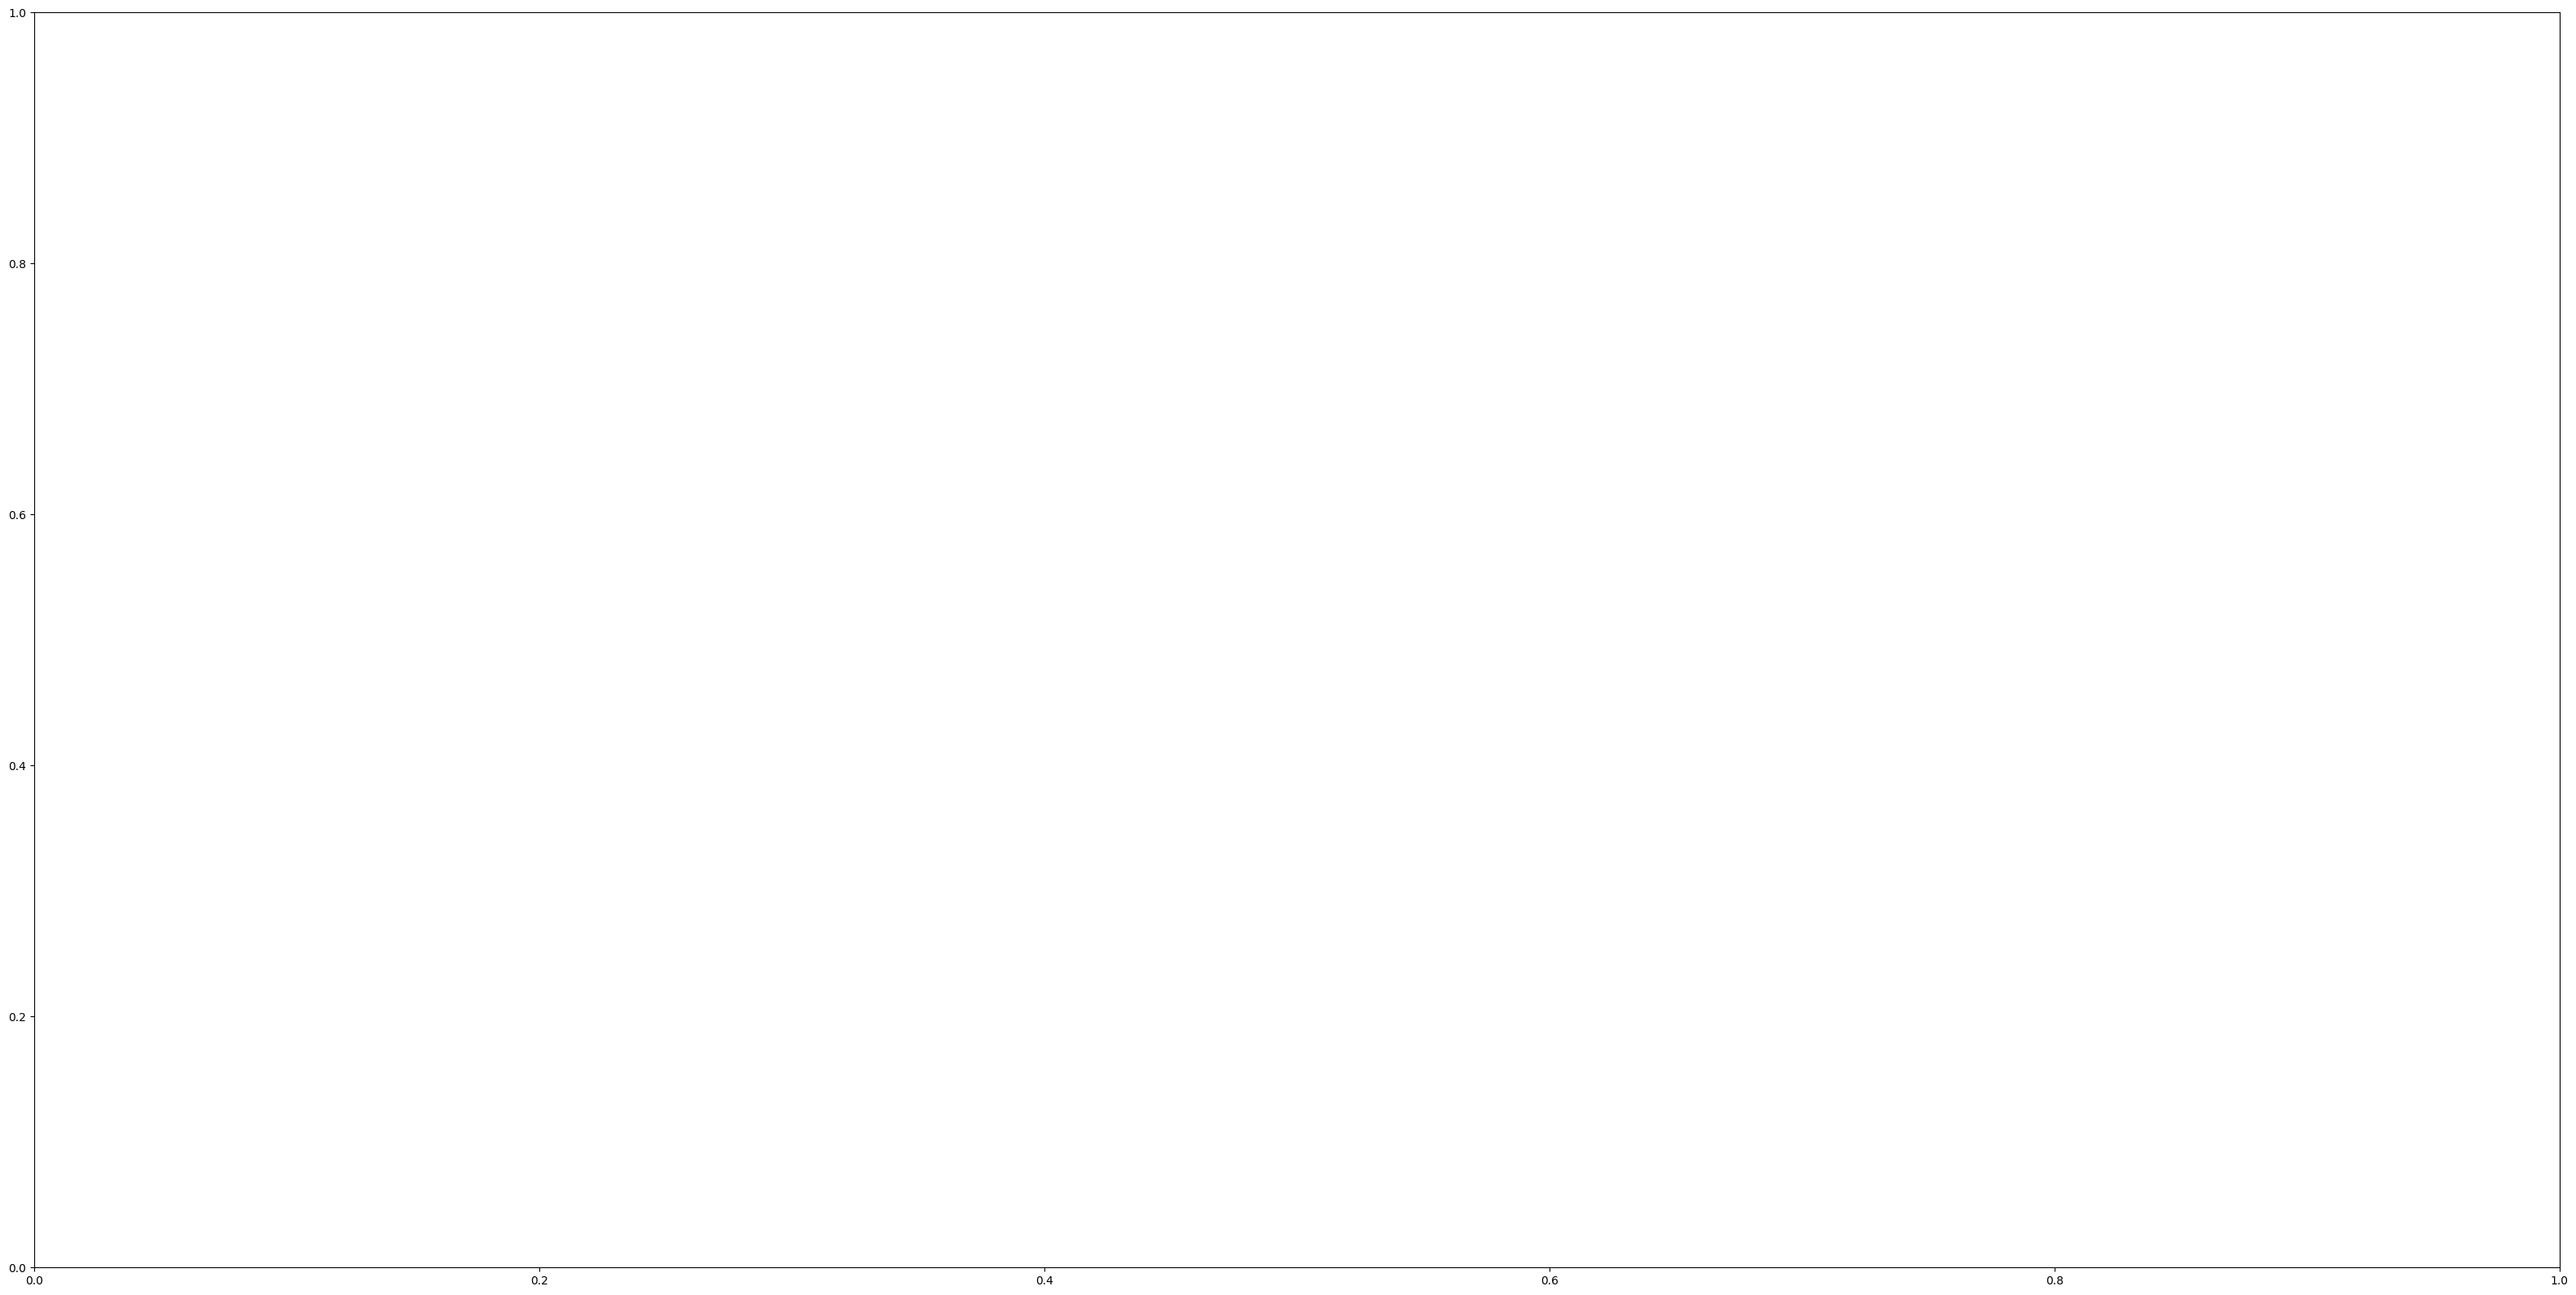

In [29]:
fig, ax = plt.subplots(figsize=(40,20), nrows=1, ncols=1, sharex=False, sharey=False)

features_df = delta_df.iloc[:, 12:-1].copy()
features_df = features_df[np.sort(features_df.columns)]
features_df[features_df > 0] = 1

estado_df = (features_df.sum()/len(features_df) ).reset_index()
estado_df.sort_values(by=0, ascending=False, inplace=True)

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[0],
            y=estado_df.columns[1],
            ax=ax,
            color="steelblue",
            # order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Object presence", fontsize=40)
sns_fig.set_ylabel(f"Number of comparisons", fontsize=0)
sns_fig.set_xlabel('', fontsize=20)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=90, labelsize=25)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=40)

# add annotation
#_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

plt.show()

In [ ]:
os.exit()

In [ ]:
# def map_label(x):
#     if x >=6.0: # 8-10
#         return "very safe"
#     elif x >=5.5: # 6-8
#         return "safe"
#     elif x>=5.0: # 4-6
#         return "upper neutral"
#     elif x>=4.0: # 4-6
#         return "lower neutral"
#     elif x >=3.0: # 3-4
#         return "unsafe"
#     else: # 0-3
#         return "very unsafe"

# def map_label(x):
#     if x >=5.5: # 8-10
#         return "safe"
#     else: # 0-3
#         return "unsafe"

In [ ]:
# data_df = data_df[ (data_df[CATEGORY]>=5.0) | (data_df[CATEGORY]<=3.0)].copy()

# data_df["labels"] = data_df[CATEGORY].apply(lambda x: map_label(x))
# # data_df["labels"] = data_df[CATEGORY].apply(lambda x: "safe" if x >= 5 else "unsafe")
# data_df = data_df[data_df["labels"].isin(["very unsafe", "unsafe", "safe", "very safe"])]


In [ ]:
delta_df["classes"] = delta_df["labels"].astype('category').cat.codes
label_map = dict(zip(delta_df["classes"], delta_df["labels"]))
labels = list(label_map.values())
classes = list(label_map.keys())
labels, classes

In [ ]:
feature_names = estado_df[estado_df[0] > 0.33]["index"].values
X_df = delta_df[np.insert(feature_names, 0, "image_id")]
y_df = delta_df[["image_id", "labels", "classes"]]
feature_names

In [ ]:
delta_df.to_csv(f"{EXPLAIN_PATH}data_delta.csv", sep=";", index=False)

### GridSearch

In [ ]:
from joblib import Memory
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [ ]:
memory = Memory(
    location=CACHE_PATH,
    # verbose=1,
)

In [ ]:
# oversampling and undersampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

def Smote(X, y):
    sm=SMOTE(random_state=RANDOM_STATE, k_neighbors=len(np.unique(y)))
    X_over, y_over = sm.fit_resample(X, y)
    return (X_over, y_over)

def overSample(X, y):
    oversample = RandomOverSampler(random_state=RANDOM_STATE)
    X_over, y_over = oversample.fit_resample(X, y)
    return (X_over, y_over)

def underSample(X, y):
    undersample = RandomUnderSampler(random_state=RANDOM_STATE)
    X_under, y_under = undersample.fit_resample(X, y)
    return (X_under, y_under)

def one_hot_encode(categories):
    unique_categories = set(categories)
    one_hot_encoded = []

    for category in categories:
        one_hot_vector = [1 if category == unique_category else 0 for unique_category in unique_categories]
        one_hot_encoded.append(one_hot_vector)

    return one_hot_encoded

In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, export_graphviz

In [ ]:
over_type="over"
over_train=True

In [ ]:
X_train_orig_df, X_test_df, y_train_orig_df, y_test_df = train_test_split(X_df, y_df, 
                                                    stratify=y_df["classes"].values,
                                                    test_size = 0.25, 
                                                    random_state = RANDOM_STATE)
X = X_df[feature_names].values
y = y_df["classes"].values

X_train_orig = X_train_orig_df[feature_names].values
y_train_orig = y_train_orig_df["classes"].values

X_test = X_test_df[feature_names].values
y_test = y_test_df["classes"].values


if over_type=="over":
    if over_train:
        X_train, y_train = overSample(X_train_orig, y_train_orig)
    else:
        X_over, y_over = overSample(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = RANDOM_STATE)
elif over_type=="under":
    if over_train:
        X_train, y_train = underSample(X_train_orig, y_train_orig)
    else:
        X_over, y_over = underSample(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = RANDOM_STATE)
elif over_type=="smote":
    if over_train:
        X_train, y_train = Smote(X_train_orig, y_train_orig)
    else:
        X_over, y_over = Smote(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = RANDOM_STATE)

else:
     X_train, y_train = X_train_orig, y_train_orig

X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
indexes_ = []
min_val = min( dict( collections.Counter(y_test) ).values() )

for cur_index in np.unique(y):
    inx_ = np.where(y_test==cur_index)[0][:min_val]
    indexes_ = np.concatenate((indexes_, inx_))

X_test_balanced = X_test[indexes_.astype(int)].copy()
y_test_balanced = y_test[indexes_.astype(int)].copy()
X_test_balanced.shape, y_test_balanced.shape

In [ ]:
collections.Counter(y_train), collections.Counter(y_test), collections.Counter(y_test_balanced), 

### Scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.linear_model import RidgeClassifier
from sklearn.multioutput import MultiOutputClassifier

In [ ]:
lr = LogisticRegression(
    tol=1e-3,
    dual=False,  # Prefer dual=False when n_samples > n_features
    random_state=RANDOM_STATE,
    max_iter=1000,
)

parameters = {'classifier__C': np.logspace(-2, 2, num=5),
            'classifier__class_weight': [None, 'balanced'],
            'classifier__penalty': ['none', 'l2'],
           }

In [ ]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', lr),
    ],
    memory=memory,
)

In [ ]:
lr_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=N_JOBS,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
lr_grid_search

In [ ]:
%%time
clf_lr = copy.deepcopy(lr_grid_search)
clf_lr.fit(X_train, y_train)

In [ ]:
clf_lr.best_score_, clf_lr.best_params_

In [ ]:
y_pred = clf_lr.predict(X_test)
clf_lr_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ],
    [ label_map[k] for k in y_pred ],
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

#### Balanced

In [ ]:
y_pred_balanced = clf_lr.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

In [ ]:
joblib.dump(clf_lr, f'{MODEL_PATH}LR_{over_type}_{round(clf_lr_report["accuracy"], 3)}.pkl')

In [ ]:
with open(f'{MODEL_PATH}LR_{over_type}_{round(clf_lr_report["accuracy"], 3)}.json', "w") as fp:
    json.dump(clf_lr_report, fp)

### Rigde Regression

In [ ]:
ridge = RidgeClassifier(
    tol=1e-3,
    random_state=RANDOM_STATE,
    max_iter=1000,
)

parameters = {'classifier__alpha': np.logspace(-2, 2, num=5),
               'classifier__class_weight': [None, 'balanced'],
              }

In [ ]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', ridge),
    ],
    memory=memory,
)

In [ ]:
ridge_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=N_JOBS,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
ridge_grid_search

In [ ]:
%%time
clf_ridge = copy.deepcopy(ridge_grid_search)
clf_ridge.fit(X_train, y_train)

In [ ]:
clf_ridge.best_score_, clf_ridge.best_params_

In [ ]:
y_pred = clf_ridge.predict(X_test)
clf_ridge_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

#### Balanced

In [ ]:
y_pred_balanced = clf_ridge.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

In [ ]:
joblib.dump(clf_ridge, f'{MODEL_PATH}Ridge_{over_type}_{round(clf_ridge_report["accuracy"], 3)}.pkl')

In [ ]:
with open(f'{MODEL_PATH}Ridge_{over_type}_{round(clf_ridge_report["accuracy"], 3)}.json', "w") as fp:
    json.dump(clf_ridge_report, fp)

### LinearSVC

In [ ]:
linear_svc = LinearSVC(
    tol=1e-3,
    random_state=42,
    max_iter=1000,
)


parameters = {'classifier__C': np.logspace(-2, 2, num=5),
              'classifier__class_weight': [None, 'balanced'],
              'classifier__penalty': ['l2'],
              'classifier__loss': ['hinge', 'squared_hinge'],
               }

In [ ]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', linear_svc),
    ],
    memory=memory,
)

In [ ]:
lsvc_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=N_JOBS,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
lsvc_grid_search

In [ ]:
%%time
clf_lsvc = copy.deepcopy(lsvc_grid_search)
clf_lsvc.fit(X_train, y_train)

In [ ]:
clf_lsvc.best_score_, clf_lsvc.best_params_

In [ ]:
y_pred = clf_lsvc.predict(X_test)
clf_lsvc_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

#### Balanced

In [ ]:
y_pred_balanced = clf_lsvc.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

In [ ]:
joblib.dump(clf_lsvc, f'{MODEL_PATH}LSVC_{over_type}_{round(clf_lsvc_report["accuracy"], 3)}.pkl')

In [ ]:
with open(f'{MODEL_PATH}LSVC_{over_type}_{round(clf_lsvc_report["accuracy"], 3)}.json', "w") as fp:
    json.dump(clf_lsvc_report, fp)

### SVC

In [ ]:
svm = SVC(
    tol=1e-3,
    random_state=42,
    max_iter=1000,
)

parameters = {'classifier__C': np.logspace(-2, 2, num=5),
             'classifier__class_weight': [None, 'balanced'],
             'classifier__gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001],
             'classifier__kernel': ['linear', 'rbf']
            }

In [ ]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', svm),
    ],
    memory=memory,
)

In [ ]:
svm_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=N_JOBS,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
svm_grid_search

In [ ]:
%%time
clf_svm = copy.deepcopy(svm_grid_search)
clf_svm.fit(X_train, y_train)

In [ ]:
clf_svm.best_score_, clf_svm.best_params_

In [ ]:
y_pred = clf_svm.predict(X_test)
clf_svm_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

#### Balanced

In [ ]:
y_pred_balanced = clf_svm.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

In [ ]:
joblib.dump(clf_svm, f'{MODEL_PATH}SVM_{over_type}_{round(clf_svm_report["accuracy"], 3)}.pkl')

In [ ]:
with open(f'{MODEL_PATH}SVM_{over_type}_{round(clf_svm_report["accuracy"], 3)}.json', "w") as fp:
    json.dump(clf_svm_report, fp)

### DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
d_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

In [ ]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # 3. Model selecction
        ('classifier', d_tree),
    ],
    memory=memory,
)

In [ ]:
parameters = {'classifier__max_features': [None, 'sqrt'],
              'classifier__max_depth': np.append(None, np.arange(10, 110, 10) ), 
              'classifier__min_samples_split': np.arange(3, 7), 
              'classifier__min_samples_leaf':np.arange(3, 7), 
             }

In [ ]:
dt_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=N_JOBS,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
dt_grid_search

In [ ]:
%%time
clf_dt = copy.deepcopy(dt_grid_search)
clf_dt.fit(X_train, y_train)

In [ ]:
clf_dt.best_score_, clf_dt.best_params_

In [ ]:
y_pred = clf_dt.predict(X_test)
clf_dt_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

#### Balanced

In [ ]:
y_pred_balanced = clf_dt.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

In [ ]:
joblib.dump(clf_dt, f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}.pkl')

In [ ]:
with open(f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}.json', "w") as fp:
    json.dump(clf_dt_report, fp)

In [ ]:
dot_data = export_graphviz(clf_dt.best_estimator_[1], out_file=None, 
                          feature_names=feature_names,  
                          class_names=labels,  
                          filled=True, rounded=True,
                          #max_depth=4,
                          special_characters=True)  

In [ ]:
graph = graphviz.Source(dot_data)
graph.render(f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}')

In [ ]:
graph = graphviz.Source(dot_data, format="png")
graph.render(f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}')

### RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
r_forest = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=600)

In [ ]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # 3. Model selecction
        ('classifier', r_forest),
    ],
    memory=memory,
)

In [ ]:
parameters = {#'classifier__n_estimators': np.arange(200, 1200, 100),
              'classifier__bootstrap': [True, False],
              # Tree parameters
              'classifier__max_features': [None, 'sqrt'],
              'classifier__max_depth': np.append(None, np.arange(10, 80, 10) ),
              'classifier__min_samples_split': np.arange(3, 5),
              'classifier__min_samples_leaf':np.arange(3, 5),
             }

In [ ]:
# parameters = {#'classifier__n_estimators': np.arange(200, 1200, 100),
#               'classifier__bootstrap': [True],
#               # Tree parameters
#               'classifier__max_features': [None],
#               'classifier__max_depth': [10],
#               'classifier__min_samples_split': [3],
#               'classifier__min_samples_leaf': [3],
#              }

In [ ]:
rf_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=N_JOBS,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
rf_grid_search

In [ ]:
%%time
clf_rf = copy.deepcopy(rf_grid_search)
clf_rf.fit(X_train, y_train)

In [ ]:
clf_rf.best_score_, clf_rf.best_params_

In [ ]:
y_pred = clf_rf.predict(X_test)
clf_rf_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

#### Balanced

In [ ]:
y_pred_balanced = clf_rf.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

In [ ]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

In [ ]:
joblib.dump(clf_rf, f'{MODEL_PATH}RF_{over_type}_{round(clf_rf_report["accuracy"], 3)}.pkl')

In [ ]:
with open(f'{MODEL_PATH}RF_{over_type}_{round(clf_rf_report["accuracy"], 3)}.json', "w") as fp:
    json.dump(clf_rf_report, fp)

In [ ]:
importances = clf_rf.best_estimator_[1].feature_importances_
std = np.std([tree.feature_importances_ for tree in clf_rf.best_estimator_[1].estimators_], axis=0)

In [ ]:
forest_importances = pd.Series(importances, index=feature_names)
forest_importances.sort_values(ascending=False, inplace=True)
forest_importances_df = forest_importances.to_frame()
forest_importances_df.reset_index(inplace=True)
forest_importances

In [ ]:
_, ax = plt.subplots(figsize=(8,12), nrows=1, ncols=1, sharex=False, sharey=False)

Top_k_features=15

sns_fig = sns.barplot(
            data=forest_importances_df.iloc[:Top_k_features],
            x=forest_importances_df.iloc[:Top_k_features].columns[1],
            y=forest_importances_df.iloc[:Top_k_features].columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            #order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Top {Top_k_features} feature importances {over_type}-Sampling", fontsize=20)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Mean decrease in impurity', fontsize=20)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=20)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=20)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%.4f', fontsize=15,rotation=0)
ax.grid(True)
# add a space on y for the annotations
#sns_fig.margins(x=0.1)
plt.savefig(f'{MODEL_PATH}RF_{over_type}_{round(clf_rf_report["accuracy"], 3)}.png')

### LIME

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

class UrbanLIME:
    def __init__(self, X, feature_names, class_names, model, target_class="safe"):
        self.data = X
        self.model = model
        self.target_class = class_names.index(target_class)
        self.feature_names = feature_names
        self.class_names = class_names
        self.class_index = list(range(len(class_names)))

        self.explainer = LimeTabularExplainer(self.data, feature_names=self.feature_names, class_names=self.class_names, discretize_continuous=True)
    
    def calculate_explanations(self, instance, target_class, num_samples=1000):
        explanation = self.explainer.explain_instance(instance, 
                                          self.model.predict_proba, 
                                          labels=self.class_index,
                                          num_features=len(self.feature_names), 
                                          num_samples=num_samples)

        ranges = self.explanation_to_ranges(explanation)

        ids_to_scores = self.explanation_to_scores(explanation, target_class)
        contributions = { self.feature_names[idx]:val for idx,val in ids_to_scores.items() }

        probs = explanation.predict_proba
        probabilities =dict(zip(self.class_names, probs))

        return contributions, ranges, probabilities

    def explanation_to_scores(self, explanation, label):
        ids_n_scores = explanation.local_exp[label]
        return dict(ids_n_scores)
            
    def explanation_to_ranges(self, explanation):
        exp = explanation.as_list()

        ranges = {}
        for feature, weight in exp:
            feature = feature.replace(">", ">=")
            feature = feature.replace("<", "<=")
            feature = feature.replace("==", "=")

            current_feature = [ f for f in feature.split(" ") if f.strip() in self.feature_names ][0]

            if "<=" in feature:
                #ranges_ = [ float( f.strip() ) for f in feature.split("<=")  ]
                ranges_ = [ float( f.strip() ) if f.strip() not in self.feature_names else f.strip() for f in feature.split("<=") ]
            elif ">=" in feature:
                ranges_ = [ f.strip() for f in feature.split(">=") ][::-1]
            else:
                ranges_ = [0.0, current_feature, 0.0]
            
            if len(ranges_)==2:
                ranges_ = [float('-inf')] + ranges_ if ranges_.index(current_feature)==0 else ranges_ + [float('inf')]
            
            ranges[current_feature] = {"weight": weight, "min": ranges_[0], "max": ranges_[2], "ranges": ranges_ }
        return ranges

In [ ]:
class UrbanExplainer:
    def __init__(self, X, feature_names, class_names, model, target_class="safe", explainer_name="lime"):
        self.X = X
        self.feature_names = feature_names
        self.class_names = class_names
        self.model = model
        self.target_class = target_class
        self.explainer_name = explainer_name
        self.get_explainer()
        
    def get_explainer(self):
        if self.explainer_name.lower()=="lime":
            self.explainer = UrbanLIME(self.X, self.feature_names, self.class_names, self.model, self.target_class)
        else:
            self.explainer = UrbanLIME(self.X, self.feature_names, self.class_names, self.model, self.target_class)
    
    def get_explanations(self):
        return self.explanation_df
    
    def calculate_explanations(self, X_data, y_data):
        ids = y_data["image_id"].values.tolist()
        X = X_data[self.feature_names].values
        y = y_data["labels"].values
        
        data_dict = {
            "image_id": [],
            "labels": [],
            "inference": [],
        }

        for k in self.class_names:
            data_dict[k] = []

        for k in self.feature_names:
            data_dict[f"{k}_exp"] = []
        
#         for idx, sample, target in tqdm(zip(ids, X, y)):
        for idx, sample, target in zip(ids, X, y):

            target_class = self.class_names.index(target)
            predict = self.model.predict([sample])[0]

            contributions, ranges, probabilities = self.explainer.calculate_explanations(sample, target_class)

            data_dict["image_id"].append( idx )
            data_dict["labels"].append( target )
            data_dict["inference"].append( self.class_names[predict] )

            max_key = max(probabilities, key=probabilities.get)
            #max_index = probabilities.index(max(probabilities))
            
            for cl in self.class_names:
                data_dict[cl].append(probabilities[cl])

            for cl in self.feature_names:
                data_dict[f"{cl}_exp"].append(contributions[cl])

        self.explanation_df = pd.DataFrame(data=data_dict)

In [ ]:
ue = UrbanExplainer(X_train, feature_names, labels, clf_rf, target_class="safe", explainer_name="lime")

In [ ]:
%%time
ue.calculate_explanations(X_df, y_df)

In [ ]:
lime_df = ue.get_explanations()
lime_df

In [ ]:
_, ax = plt.subplots(figsize=(30,16), nrows=1, ncols=1, sharex=False, sharey=False, constrained_layout=True)


lime_bar = lime_df[[f"{f}_exp" for f in feature_names]].copy()
lime_bar.columns = [f"{f}" for f in feature_names]

lime_exploded = lime_bar.melt(var_name='features', value_name='value')


sns_fig_bar = sns.boxplot(data=lime_exploded,
                            x="features", 
                            y="value", 
                            dodge=True,
                            showfliers=True, 
                            notch=True,
                            patch_artist=True,
                            medianprops=dict(color="orange", linewidth=10),
                            boxprops=dict(facecolor='lightblue', linewidth=5),
                            whiskerprops=dict(color='red', linewidth=5),
                            capprops=dict(color='green', linewidth=5),
                            flierprops=dict(marker='o', color='purple', alpha=0.95, markersize=30),
                            ax=ax
                           )

# rotate the axis ticklabels
_ = sns_fig_bar.tick_params(axis='x', rotation=0, labelsize=40)


# rotate the axis ticklabels
_ = sns_fig_bar.tick_params(axis='y', rotation=0, labelsize=40)

sns_fig_bar.yaxis.grid(True)
sns_fig_bar.xaxis.grid(True)
# ax.set_title(f"CVE-CVSS V2 Score by label, Avg: {round(df['cvss_score_V2'].mean(), 2)}", fontsize=30)
sns_fig_bar.set_xlabel('Label', fontsize=0)
sns_fig_bar.set_ylabel(f"Presence impact", fontsize=50)


a,b = ax.get_ylim()
ax.set_ylim(-0.15, 0.15)

In [ ]:
plt.figure(figsize=(10, 6))
lime_df[[f"{f}_exp" for f in feature_names]].boxplot(
    notch=True,          # Notched boxplot
    patch_artist=True,   # Fill with color
    boxprops=dict(facecolor='lightblue', color='blue'),
    whiskerprops=dict(color='red'),
    capprops=dict(color='green'),
    flierprops=dict(marker='o', color='purple', alpha=0.5),
    medianprops=dict(color='orange')
)

plt.title('Differenece original vs mean')
plt.xlabel('Category')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [ ]:
lime_df["labels"].value_counts()

In [ ]:
lime_df["inference"].value_counts()

In [ ]:
lime_df.to_csv(f"{EXPLAIN_PATH}Lime.csv", sep=";", index=False)

In [ ]:
# Convert the Series to a DataFrame to work with seaborn
df = lime_df.iloc[0,5:].reset_index()
label = lime_df.loc[0,"labels"]
df.columns = ['Category', 'Value']
df["Category"] = df["Category"].apply(lambda x: x.replace("_exp", "").capitalize())

# Plot with seaborn
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Value', 
    y='Category', 
            color="steelblue",
    data=df, 
)

plt.xticks(rotation=0, ha='right')
plt.title(f'LIME explanation, label: {label}')
plt.xlabel('Value')
plt.ylabel('')
plt.grid()
plt.show()

#### Testing LIME

In [ ]:
explainer = LimeTabularExplainer(X_train, feature_names=feature_names, class_names=labels, discretize_continuous=True)
instance = X_test[0]

In [ ]:
explanation = explainer.explain_instance(instance, 
                                          clf_rf.predict_proba, 
                                          labels=[0],
                                          num_features=len(feature_names), 
                                          num_samples=1000)
explanation.show_in_notebook(show_table=True, show_all=False)

In [ ]:
explanation = explainer.explain_instance(instance, 
                                          clf_rf.predict_proba, 
                                          labels=[1],
                                          num_features=len(feature_names), 
                                          num_samples=1000)
explanation.show_in_notebook(show_table=True, show_all=False)

#### Explanation
In this example:

* **Range Values**: feature_range represents the discretized range of each feature used by LIME. For instance, if LIME discretizes a continuous feature like petal width into bins, feature_range would show the range of values within that bin.
* **Fixed Value**: `feature_values[feature_idx]` shows the actual value of the feature in the instance being explained.

#### Interpretation
* LIME discretizes continuous features into intervals (range values) to simplify the local explanation process. The fixed value is the specific value of each feature in the instance being explained.
* Together, the range values and fixed values help LIME generate local surrogate models that approximate how changes in feature values affect the model's predictions locally around the explained instance.

### SHAP

In [ ]:
import shap
shap.initjs()

In [ ]:
#LinearExplainer
shap_explainer = shap.Explainer(clf_rf.best_estimator_[1], X_train)

In [ ]:
instance = X_test[0].reshape(1, -1)
contributions = shap_explainer(instance)#, check_additivity=False)
dict(zip(feature_names, contributions[0].values))

In [ ]:
shap_values_instance = shap_explainer.shap_values(instance)

In [ ]:
_, ax = plt.subplots(figsize=(25,12), nrows=1, ncols=1, sharex=False, sharey=False)
xdim, _, zdim = np.array(shap_values_instance).shape
shap_values_instance_narray = np.array(shap_values_instance).reshape(xdim, zdim)#*10
shap_values_df = pd.DataFrame(shap_values_instance_narray, columns=feature_names).abs()
#shap_values_df.index = [ label_map[idx] for idx in list(shap_values_df.index) ]
shap_values_melt_df = pd.melt(shap_values_df.T.reset_index(), id_vars="index", var_name="label", value_name="value")
mean_shap_values_df = shap_values_df.abs().sum().sort_values(ascending=False).reset_index()

top_k_features_names = mean_shap_values_df["index"][:15].values.tolist()
sort_df = shap_values_melt_df[ shap_values_melt_df["index"].isin(top_k_features_names) ]
sort_df['index'] = pd.Categorical(sort_df['index'], categories=top_k_features_names, ordered=True)
sort_df.sort_values(by=['index', 'label'], inplace=True)
sort_df["label"] = sort_df["label"].apply(lambda x: label_map[x])
pivot_df = sort_df.pivot_table(index='index', columns='label', values='value', aggfunc=np.sum, fill_value=0)

pivot_df.plot(kind='bar', stacked=True, ax=ax)
ax.set_title(f"Top feature average impacts", fontsize=0)
ax.set_ylabel(f"Label", fontsize=0)
ax.set_xlabel('Mean decrease in impurity', fontsize=0)

# rotate the axis ticklabels
_ = ax.tick_params(axis='x', rotation=50, labelsize=40)

# rotate the axis ticklabels
_ = ax.tick_params(axis='y', labelsize=40)

# add annotation
# _ = ax.bar_label(sns_fig.containers[0], fmt='%.4f', fontsize=15,rotation=0)

# add legend
ax.legend(fontsize=40)
a,b = ax.get_ylim()
ax.set_ylim(a, b+0.001)

ax.grid(True)

In [ ]:
# Plot the SHAP values
_, ax = plt.subplots(figsize=(24,16), nrows=1, ncols=1, sharex=False, sharey=False)
ax.set_title(f"Top {Top_k_features} feature impact means {over_type}-Sampling", fontsize=20)
ax.grid(True)
shap.summary_plot(shap_values_instance, instance, feature_names=feature_names, show=False, class_names=labels)